# Econ 8208 Assignment 5

- Author: Yuxuan Zhao
- Date: 2026-04-01

In [67]:
using LinearAlgebra
# Using defined functions in ECON8208Tools.jl
include("../ECON8208Tools.jl")
using .ECON8208Tools


# HW 5

Compute the following growth model:


\begin{aligned}
\max_{\{c_t,x_t,\ell_t\}} \quad & E \sum_{t=0}^{\infty} \beta^t 
\left\{ \frac{(c_t \ell_t^{\psi})^{1-\sigma}}{1-\sigma} \right\} N_t \\
\text{s.t.} \quad 
& c_t + x_t = k_t^{\theta}\bigl((1+\gamma_z)^t z_t h_t\bigr)^{1-\theta}, \\
& N_{t+1}  k_{t+1} = \bigl[(1-\delta)k_t + x_t\bigr] N_t, \\
& \log z_t = \rho \log z_{t-1} + \epsilon_t, \qquad \epsilon_t \sim N(0,\sigma_\epsilon^2), \\
& h_t + \ell_t = 1, \\
& N_t = (1+\gamma_n)^t, \\
& k_0 \text{ given.}
\end{aligned}


This model implies a balanced growth path, the grid of the state variable $k_t$ will grow over time, and we cannot solve the model using value function iteration, thus we need to detrend the variables to solve the model.

Define the detrended variables as follows:
\begin{aligned}
\tilde{c}_t = \frac{c_t}{(1+\gamma_n)^t}, \quad
\tilde{x}_t = \frac{x_t}{(1+\gamma_n)^t}, \quad
\tilde{k}_t = \frac{k_t}{(1+\gamma_n)^t}, \quad
\tilde{h}_t = h_t, \quad
\tilde{\ell}_t = \ell_t.
\end{aligned}

The detrended problem can be written as:
\begin{aligned}
\max_{\{\tilde{c}_t,\tilde{x}_t,\tilde{\ell}_t\}} \quad & E \sum_{t=0}^{\infty} \beta^t 
\left\{ \frac{(\tilde{c}_t \tilde{\ell}_t^{\psi})^{1-\sigma}}{1-\sigma} \right\} \\
\text{s.t.} \quad
& \tilde{c}_t + \tilde{x}_t = \tilde{k}_t^{\theta}\bigl( z_t \tilde{h}_t\bigr)^{1-\theta}, \\
& \tilde{k}_{t+1} = \frac{(1-\delta)\tilde{k}_t + \tilde{x}_t}{1+\gamma_n}, \\
& \log z_t = \rho \log z_{t-1} + \epsilon_t, \qquad \epsilon_t \sim N(0,\sigma_\epsilon^2), \\
& \tilde{h}_t + \tilde{\ell}_t = 1, \\
& \tilde{k}_0 = k_0.
\end{aligned}

In [68]:
# -------------------------------------------------------
# Initialize parameters
# -------------------------------------------------------

beta = 0.96          # discount factor
psi = 1.50          # utility weight on leisure
sigma = 2.00          # coefficient of relative risk aversion
gamma_n = 0.01        # population growth rate
gamma_z = 0.02        # labor-augmenting technology growth rate
theta = 0.36          # capital share in production
delta = 0.08          # depreciation rate
rho = 0.90          # persistence of productivity shock
sigma_e = 0.02        # standard deviation of productivity shock

# -------------------------------------------------------
# Additional settings for computation
# -------------------------------------------------------

n_k = 500         # number of grid points for capital
n_h = 1000          # number of grid points for hours worked
n_z = 2           # number of grid points for productivity
tol = 1e-5        # convergence tolerance
max_iter = 1000   # maximum number of iterations

# -------------------------------------------------------
# Initial productivity state
# -------------------------------------------------------

z_ss = 1.0        # steady-state productivity
logz_ss = 0.0     # steady-state log productivity

# -------------------------------------------------------
# Initial capital condition
# Will be updated after computing steady-state capital
# -------------------------------------------------------

k0 = nothing




## Helper functions

### Numerical approximation of the standard normal CDF

Tauchen's method requires repeated evaluation of the standard normal cumulative distribution function
$$
\Phi(x) = \int_{-\infty}^x \frac{1}{\sqrt{2\pi}} e^{-t^2/2} dt.
$$

Since $\Phi(x)$ does not have a closed-form expression in elementary functions, we approximate it numerically.

A common approximation writes $\Phi(x)$ as a function of the standard normal density
$$
\phi(x) = \frac{1}{\sqrt{2\pi}} e^{-x^2/2},
$$
and a polynomial in
$$
t = \frac{1}{1 + p |x|},
$$
where $p$ is a constant.

For $x \ge 0$, the approximation is
$$
\Phi(x)
\approx
1 - \phi(x)\left(b_1 t + b_2 t^2 + b_3 t^3 + b_4 t^4 + b_5 t^5\right),
$$
where
$$
b_1 = 0.319381530,\quad
b_2 = -0.356563782,\quad
b_3 = 1.781477937,\quad
b_4 = -1.821255978,\quad
b_5 = 1.330274429,
$$
and
$$
p = 0.2316419.
$$

For $x < 0$, we use the symmetry property of the standard normal distribution:
$$
\Phi(x) = 1 - \Phi(-x).
$$

### Pseudocode for numerical approximation of $\Phi(x)$

**Input:** $x$

**Output:** $\Phi(x)$

**Algorithm:**

1. Set the approximation constants $b_1, b_2, b_3, b_4, b_5$, and $p$.
2. Compute
   $$
   t = \frac{1}{1 + p|x|}.
   $$
3. Compute the standard normal density
   $$
   \phi(x) = \frac{1}{\sqrt{2\pi}} e^{-x^2/2}.
   $$
4. Compute the approximation for the positive case:
   $$
   \Phi_+(x)
   =
   1 - \phi(x)\left(b_1 t + b_2 t^2 + b_3 t^3 + b_4 t^4 + b_5 t^5\right).
   $$
5. If $x \ge 0$, return $\Phi_+(x)$.
6. Otherwise, return
   $$
   1 - \Phi_+(x).
   $$




In [69]:
# -------------------------------------------------------
# Standard normal cumulative distribution function
# Numerical approximation without external packages
# Input:
#   x : scalar
# Output:
#   Phi(x)
# -------------------------------------------------------
function normcdf(x)
    b1 = 0.319381530
    b2 = -0.356563782
    b3 = 1.781477937
    b4 = -1.821255978
    b5 = 1.330274429
    p = 0.2316419

    t = 1.0 / (1.0 + p * abs(x))
    pdf = exp(-0.5 * x^2) / sqrt(2.0 * pi)

    cdf_pos = 1.0 - pdf * (b1 * t + b2 * t^2 + b3 * t^3 + b4 * t^4 + b5 * t^5)

    if x >= 0.0
        return cdf_pos
    else
        return 1.0 - cdf_pos
    end
end


normcdf (generic function with 1 method)

Test the numerical approximation of $\Phi(x)$ against a standard normal cumulative distribution function to ensure accuracy.

Below I used Distributions.jl's `cdf` function to compute the exact value of $\Phi(x)$ for a standard normal distribution, and compared it with the approximation defined above. 

The results show that the approximation is very close to the exact values, with small absolute errors across a range of $x$ values from -4 to 4.

However, I won't use Distributions package in the actual implementation.

In [70]:
# -------------------------------------------------------
# Test the numerical approximation of normcdf
# Input:
#   x : scalar
# Output:
#   Print a table comparing normcdf with Distributions.jl's cdf for a range of x values
# -------------------------------------------------------

# Just for testing, I want to compare defined normcdf with Distributions.jl's cdf, make sure they are close enough
using Distributions

x_test = collect(range(-4.0, 4.0, length=17))

println("      x        approx        exact        abs error")
println("------------------------------------------------------")

for x in x_test
    approx_val = normcdf(x)
    exact_val = cdf(Normal(), x)
    err = abs(approx_val - exact_val)

    println(rpad(round(x, digits=4), 10),
            lpad(round(approx_val, digits=8), 14),
            lpad(round(exact_val, digits=8), 14),
            lpad(round(err, digits=10), 16))
end


      x        approx        exact        abs error
------------------------------------------------------
-4.0            3.169e-5      3.167e-5         1.48e-8
-3.5          0.00023267    0.00023263         4.43e-8
-3.0          0.00134997     0.0013499         6.92e-8
-2.5          0.00620968    0.00620967         1.45e-8
-2.0          0.02275006    0.02275013         6.99e-8
-1.5          0.06680723     0.0668072         2.75e-8
-1.0          0.15865526    0.15865525          5.6e-9
-0.5          0.30853753    0.30853754          6.5e-9
0.0                  0.5           0.5         5.0e-10
0.5           0.69146247    0.69146246          6.5e-9
1.0           0.84134474    0.84134475          5.6e-9
1.5           0.93319277     0.9331928         2.75e-8
2.0           0.97724994    0.97724987         6.99e-8
2.5           0.99379032    0.99379033         1.45e-8
3.0           0.99865003     0.9986501         6.92e-8
3.5           0.99976733    0.99976737         4.43e-8
4.0          

### Tauchen discretization for AR(1) process

$z_t$ follows an AR(1) process. To solve the model, we need to discretize the state space of $z_t$ using Tauchen's method.

Suppose the productivity shock satisfies
$$
\log z_t = \rho \log z_{t-1} + \epsilon_t,
\qquad
\epsilon_t \sim N(0,\sigma_\epsilon^2).
$$

Let
$$
y_t = \log z_t.
$$
Then the process becomes
$$
y_t = \rho y_{t-1} + \epsilon_t.
$$

The unconditional standard deviation of $y_t$ is
$$
\sigma_y = \frac{\sigma_\epsilon}{\sqrt{1-\rho^2}}.
$$

Tauchen's method approximates this continuous AR(1) process by a finite-state Markov chain.  
First, we construct an evenly spaced grid for $y_t$ over the interval
$$
[-m\sigma_y,\; m\sigma_y],
$$
where $m$ is typically chosen as 3.

Let the grid points be
$$
y_1, y_2, \dots, y_{n_z},
$$
with step size
$$
\Delta = y_{j+1} - y_j.
$$

Then, for each current state $y_i$, we compute the transition probability to each future state $y_j$ using the normal distribution implied by
$$
y_{t+1} \mid y_t = y_i \sim N(\rho y_i,\sigma_\epsilon^2).
$$

For interior grid points,
$$
P_{ij}
=
\Pr\left(
y_j - \frac{\Delta}{2}
\le y_{t+1}
\le
y_j + \frac{\Delta}{2}
\;\middle|\;
y_t = y_i
\right).
$$

For the lower and upper boundary points,
$$
P_{i1}
=
\Pr\left(
y_{t+1}
\le
y_1 + \frac{\Delta}{2}
\;\middle|\;
y_t = y_i
\right),
$$
and
$$
P_{in_z}
=
\Pr\left(
y_{t+1}
\ge
y_{n_z} - \frac{\Delta}{2}
\;\middle|\;
y_t = y_i
\right).
$$

Finally, we exponentiate the grid to recover the productivity levels:
$$
z_j = e^{y_j}, \qquad j=1,\dots,n_z.
$$

### Pseudocode for Tauchen discretization

**Input:** $\rho, \sigma_\epsilon, n_z, m$

**Output:** $z$-grid, transition matrix $P$

**Algorithm:**

1. Compute the unconditional standard deviation
   $$
   \sigma_y = \frac{\sigma_\epsilon}{\sqrt{1-\rho^2}}.
   $$
2. Construct an evenly spaced grid for $y = \log z$ over
   $$
   [-m\sigma_y,\; m\sigma_y].
   $$
3. Compute the grid step size $\Delta$.
4. For each current grid point $y_i$:
   - For each future grid point $y_j$:
     - If $j=1$, compute the lower-tail transition probability.
     - If $j=n_z$, compute the upper-tail transition probability.
     - Otherwise, compute the probability of moving into the interval
       $$
       \left[y_j-\frac{\Delta}{2},\; y_j+\frac{\Delta}{2}\right].
       $$
5. Form the transition matrix $P$.
6. Set
   $$
   z_j = e^{y_j}
   $$
   for each grid point.
7. Return the $z$-grid and the transition matrix $P$.

In [71]:
# -------------------------------------------------------
# Tauchen discretization for log z_t = rho * log z_{t-1} + eps_t
# Input:
#   rho      : persistence parameter
#   sigma_e  : standard deviation of innovation
#   n_z      : number of grid points
#   m        : width parameter for Tauchen grid (default: 3.0)
# Output:
#   z_grid   : productivity grid in levels
#   Pz       : Markov transition matrix
# -------------------------------------------------------
function tauchen(rho, sigma_e, n_z; m=3.0)
    sigma_z = sigma_e / sqrt(1.0 - rho^2)
    logz_max = m * sigma_z
    logz_min = -m * sigma_z

    logz_grid = collect(range(logz_min, logz_max, length=n_z))
    step = logz_grid[2] - logz_grid[1]

    Pz = zeros(n_z, n_z)

    for i in 1:n_z
        for j in 1:n_z
            if j == 1
                cutoff = (logz_grid[1] - rho * logz_grid[i] + step / 2.0) / sigma_e
                Pz[i, j] = normcdf(cutoff)
            elseif j == n_z
                cutoff = (logz_grid[n_z] - rho * logz_grid[i] - step / 2.0) / sigma_e
                Pz[i, j] = 1.0 - normcdf(cutoff)
            else
                upper = (logz_grid[j] - rho * logz_grid[i] + step / 2.0) / sigma_e
                lower = (logz_grid[j] - rho * logz_grid[i] - step / 2.0) / sigma_e
                Pz[i, j] = normcdf(upper) - normcdf(lower)
            end
        end
    end

    z_grid = exp.(logz_grid)

    return z_grid, Pz
end


tauchen (generic function with 1 method)

In [72]:
# --------------------------------------------------------
# Test the Tauchen discretization function
# Input parameters for testing:
#   rho = 0.90
#   sigma_e = 0.02
#   n_z = 5
# Output:
#   z_grid : productivity grid in levels
#   Pz     : Markov transition matrix
# Verify that each row of Pz sums to 1
# --------------------------------------------------------

# Construct productivity grid and transition matrix
z_grid, Pz = tauchen(rho, sigma_e, n_z)

println("Productivity grid (z_grid):")
println(z_grid)
println("\nTransition matrix (Pz):")
println(Pz)

# Verify that each row of Pz sums to 1
row_sums = sum(Pz, dims=2)
println("\nRow sums of Pz (should be 1):")
println(row_sums)

Productivity grid (z_grid):
[0.8714041173542129, 1.1475731868656236]

Transition matrix (Pz):
[0.9999999997059428 2.9405722301589776e-10; 2.9405722301589776e-10 0.9999999997059428]

Row sums of Pz (should be 1):
[1.0; 1.0;;]


## a) Solve the model using value function iteration.

We can rewrite HH problem as Bellman equation as follows:
\begin{aligned}
V(\tilde{k}, z) = \max_{\tilde{c}, \tilde{x}, \tilde{\ell}} \quad & 
\left\{ \frac{(\tilde{c} \tilde{\ell}^{\psi})^{1-\sigma}}{1-\sigma} + \beta E V(\tilde{k}', z') \right\} \\
\text{s.t.} \quad
& \tilde{c} + \tilde{x} = \tilde{k}^{\theta}\bigl( z \tilde{h}\bigr)^{1-\theta}, \\
& \tilde{k}' = \frac{(1-\delta)\tilde{k} + \tilde{x}}{1+\gamma_n}, \\
& \log z = \rho \log z + \epsilon, \qquad \epsilon \sim N(0,\sigma_\epsilon^2), \\
& \tilde{h} + \tilde{\ell} = 1, \\
& \tilde{k}_0 = k_0.
\end{aligned}

Further simplify the Bellman equation, we have:
$$
\begin{aligned}
V(\tilde{k},z)
=
\max_{\tilde{k}',\,\tilde{h}}
\quad
\Biggl\{
&
\frac{
\left[
\left(
\tilde{k}^\theta (z \tilde{h})^{1-\theta}
-
(1+\gamma_n)\tilde{k}'
+
(1-\delta)\tilde{k}
\right)
(1-\tilde{h})^\psi
\right]^{1-\sigma}
}{1-\sigma}
+ \beta E\bigl[V(\tilde{k}',z')\bigr]
\Biggr\}, \\
\text{s.t.} \quad
& \log z' = \rho \log z + \epsilon',
\qquad
\epsilon' \sim N(0,\sigma_\epsilon^2), \\
& \tilde{k}' \ge 0, \\
& 0 \le \tilde{h} \le 1, \\
& \tilde{c} > 0,
\end{aligned}
$$




### Grid construction for value function iteration

1. **Construct asset grids**
After discretizing the productivity process, we obtain the grid
$$
z_1, z_2, \dots, z_{n_z},
$$
and the transition matrix $P_z$.

Let
$$
z_{\max} = \max \{ z_1, z_2, \dots, z_{n_z} \}.
$$

2. **Construct capital grids**

To construct the capital grid, we first compute the maximum sustainable capital stock.  

Firstly we assume that all output is invested, labor is at its maximum, then we have:
$$
\begin{aligned}
\tilde{k}_{t+1} &= \frac{(1-\delta)\tilde{k}_t}{1+\gamma_n} + \frac{\tilde{x}_t}{1+\gamma_n} \\
&= \frac{(1-\delta)\tilde{k}_t}{1+\gamma_n} + \frac{\tilde{k}_t^\theta z_t^{\,1-\theta}}{1+\gamma_n} \\
\implies
\tilde{k}_{t+1} - \tilde{k}_{t} & = \left( \frac{(1-\delta)}{1+\gamma_n} - 1 \right) \tilde{k}_t + \frac{\tilde{k}_t^\theta z_t^{\,1-\theta}}{1+\gamma_n}.
\end{aligned}   
$$

Then maximum sustainable capital stock is the one that satisfies $\tilde{k}_{t+1} = \tilde{k}_t$, which implies
$$
\left( \frac{(1-\delta)}{1+\gamma_n} - 1 \right) \tilde{k}_{\max} + \frac{\tilde{k}_{\max}^\theta z_{\max}^{\,1-\theta}}{1+\gamma_n} = 0 \\
\implies
\tilde{k}_{\max} = \left[\frac{z_{\max}^{\,1-\theta}}{\gamma_n + \delta} \right]^{\frac{1}{1-\theta}}
$$


Then we construct an evenly spaced grid for capital over the interval
$$
\left[0,\max \{\tilde{k}_{\max},k_0\}\right]
$$
with $n_k$ grid points.


1. **Construct labor grids**


Similarly, we construct an evenly spaced grid for labor over the interval
$$
[0,1]
$$
with $n_h$ grid points. 



In [73]:
# -------------------------------------------------------
# Grid construction
# -------------------------------------------------------

# Construct productivity grid and transition matrix
z_grid, Pz = tauchen(rho, sigma_e, n_z)

# Maximum productivity level on the discretized grid
z_max = maximum(z_grid)

# -------------------------------------------------------
# Construct capital grid
# The maximum sustainable capital stock satisfies
#   k_{t+1} = k_t
# when all output is invested and labor is at its maximum
# -------------------------------------------------------
k_max = (z_max^(1.0 - theta) / (gamma_n + delta))^(1.0 / (1.0 - theta))

# Upper bound for the capital grid
k_upper = max(k_max, k0 === nothing ? 0.0 : k0)

# Evenly spaced capital grid on [0, max{k_max, k0}]
tolk = 1e-4
k_grid = collect(range(tolk, k_upper, length=n_k))

# -------------------------------------------------------
# Construct labor grid
# Evenly spaced labor grid on [0, 1]
# -------------------------------------------------------
tolh = 1e-4
h_grid = collect(range(tolh, 1.0-tolh, length=n_h))

println("z_max = ", z_max)
println("k_max = ", k_max)
println("capital grid lower bound = ", first(k_grid))
println("capital grid upper bound = ", last(k_grid))
println("labor grid lower bound = ", first(h_grid))
println("labor grid upper bound = ", last(h_grid))


z_max = 1.1475731868656236
k_max = 49.405633385742696
capital grid lower bound = 0.0001
capital grid upper bound = 49.405633385742696
labor grid lower bound = 0.0001
labor grid upper bound = 0.9999


Let
$$
\tilde{k}_i \in \{\tilde{k}_1,\dots,\tilde{k}_{n_k}\},
\qquad
z_j \in \{z_1,\dots,z_{n_z}\},
\qquad
\tilde{h}_m \in \{\tilde{h}_1,\dots,\tilde{h}_{n_h}\}.
$$

Let $\Pi_z(z,z')$ denote the transition probability from current productivity state $z$ to next-period productivity state $z'$.

Solve the HH problem:
$$
\begin{aligned}
V(\tilde{k},z)
=
\max_{\tilde{k}',\,\tilde{h}}
\quad
\Biggl\{
&
\frac{
\left[
\left(
\tilde{k}^\theta (z \tilde{h})^{1-\theta}
-
(1+\gamma_n)\tilde{k}'
+
(1-\delta)\tilde{k}
\right)
(1-\tilde{h})^\psi
\right]^{1-\sigma}
}{1-\sigma}
+ \beta
\sum_{z' \in Z}
\Pi_z(z,z')\,V(\tilde{k}',z')
\Biggr\}, \\
\text{s.t.} \quad
& z' | z \sim P_z(z,z'), \\
& \tilde{k}' \ge 0, \\
& 0 \le \tilde{h} \le 1, \\
& \tilde{c} > 0
\end{aligned}
$$




In [74]:
# -------------------------------------------------------
# Flow utility function
# Input:
#   c     : detrended consumption
#   h     : labor
#   psi   : leisure weight
#   sigma : coefficient of relative risk aversion
# Output:
#   period utility
# -------------------------------------------------------
function flow_utility(c, h, psi, sigma)

    if c <= 0.0 || h < 0.0 || h > 1.0
        return -Inf
    end

    return ((c * (1.0 - h)^psi)^(1.0 - sigma)) / (1.0 - sigma)
end

# -------------------------------------------------------
# Solve the detrended growth model by value function iteration
# State variables:
#   (k_tilde, z)
# Control variables:
#   (k_tilde_next, h)
# Input:
#   beta, psi, sigma, gamma_n, theta, delta
#   k_grid, h_grid, z_grid, Pz
#   tol, max_iter
# Output:
#   V          : value function
#   pol_kp     : policy function for next-period capital
#   pol_h      : policy function for labor
# -------------------------------------------------------
function solve_vfi_growth(beta, psi, sigma, gamma_n, theta, delta,
                          k_grid, h_grid, z_grid, Pz;
                          tol=1e-6, max_iter=1000)

    n_k = length(k_grid)
    n_h = length(h_grid)
    n_z = length(z_grid)

    V = zeros(n_k, n_z)
    V_new = similar(V)

    pol_kp = zeros(n_k, n_z)
    pol_h = zeros(n_k, n_z)

    for iter in 1:max_iter
        for iz in 1:n_z
            z = z_grid[iz]

            for ik in 1:n_k
                k = k_grid[ik]

                best_val = -Inf
                best_kp = k_grid[1]
                best_h = h_grid[1]

                for ih in 1:n_h
                    h = h_grid[ih]

                    output = k^theta * (z * h)^(1.0 - theta)

                    for ikp in 1:n_k
                        kp = k_grid[ikp]

                        c = output - (1.0 + gamma_n) * kp + (1.0 - delta) * k
                        u = flow_utility(c, h, psi, sigma)

                        if !isfinite(u)
                            continue
                        end

                        EV = 0.0
                        for izp in 1:n_z
                            EV += Pz[iz, izp] * V[ikp, izp]
                        end

                        val = u + beta * EV

                        if val > best_val
                            best_val = val
                            best_kp = kp
                            best_h = h
                        end
                    end
                end

                V_new[ik, iz] = best_val
                pol_kp[ik, iz] = best_kp
                pol_h[ik, iz] = best_h
            end
        end

        err = maximum(abs.(V_new .- V))
        V .= V_new

        println("VFI iteration = ", iter, ", error = ", err)

        if err < tol
            println("VFI converged in ", iter, " iterations.")
            return V, pol_kp, pol_h
        end
    end

    error("VFI did not converge within max_iter.")
end


solve_vfi_growth (generic function with 1 method)

In [75]:
#=
# -------------------------------------------------------
# Test value function iteration
# -------------------------------------------------------

V, pol_kp, pol_h = solve_vfi_growth(
    beta, psi, sigma, gamma_n, theta, delta,
    k_grid, h_grid, z_grid, Pz;
    tol=tol, max_iter=max_iter
)
=#


In [76]:
#=
using Plots

# -------------------------------------------------------
# Plot policy functions
# Horizontal axis: current capital k
# Vertical axis: policy values
# Different productivity states z are shown as different lines
# -------------------------------------------------------

# Plot policy function for next-period capital k'(k, z)
p1 = plot(
    xlabel = "Current capital k",
    ylabel = "Next-period capital k'",
    title = "Policy Function for k'(k, z)",
    linewidth = 2
)

for iz in 1:length(z_grid)
    plot!(
        p1,
        k_grid,
        pol_kp[:, iz],
        label = "z = $(round(z_grid[iz], digits=3))"
    )
end

# Plot policy function for labor h(k, z)
p2 = plot(
    xlabel = "Current capital k",
    ylabel = "Labor h",
    title = "Policy Function for h(k, z)",
    linewidth = 2
)

for iz in 1:length(z_grid)
    plot!(
        p2,
        k_grid,
        pol_h[:, iz],
        label = "z = $(round(z_grid[iz], digits=3))"
    )
end

plot(p1, p2, layout = (1, 2), size = (1100, 400))
=#


## 5. Howard Policy Function Iteration (PFI)

Solve the HH problem:
$$
\begin{aligned}
V(\tilde{k},z)
=
\max_{\tilde{k}',\,\tilde{h}}
\quad
\Biggl\{
&
\frac{
\left[
\left(
\tilde{k}^\theta (z \tilde{h})^{1-\theta}
-
(1+\gamma_n)\tilde{k}'
+
(1-\delta)\tilde{k}
\right)
(1-\tilde{h})^\psi
\right]^{1-\sigma}
}{1-\sigma}
+ \beta
\sum_{z' \in Z}
\Pi_z(z,z')\,V(\tilde{k}',z')
\Biggr\}, \\
\text{s.t.} \quad
& z' \mid z \sim P_z(z,z'), \\
& \tilde{k}' \ge 0, \\
& 0 \le \tilde{h} \le 1, \\
& \tilde{c} > 0.
\end{aligned}
$$

Howard policy function iteration speeds up the solution by separating policy improvement from policy evaluation.

1. **Initialize**

- Set an initial value function $V_0(\tilde{k},z)$.
- Set initial policy functions
  $$
  g_k^0(\tilde{k},z), \qquad g_h^0(\tilde{k},z).
  $$

2. **Policy Improvement**

- Given the current value function $V_n(\tilde{k},z)$, solve
  $$
  \left(g_k^{n+1}(\tilde{k},z),\,g_h^{n+1}(\tilde{k},z)\right)
  =
  \arg\max_{\tilde{k}',\,\tilde{h}}
  \Biggl\{
  \frac{
  \left[
  \left(
  \tilde{k}^\theta (z \tilde{h})^{1-\theta}
  -
  (1+\gamma_n)\tilde{k}'
  +
  (1-\delta)\tilde{k}
  \right)
  (1-\tilde{h})^\psi
  \right]^{1-\sigma}
  }{1-\sigma}
  +
  \beta
  \sum_{z' \in Z}
  \Pi_z(z,z')\,V_n(\tilde{k}',z')
  \Biggr\},
  $$
  subject to
  $$
  \tilde{k}' \ge 0, \qquad 0 \le \tilde{h} \le 1, \qquad \tilde{c} > 0.
  $$

3. **Policy Evaluation**

- Hold the policy functions fixed at
  $$
  g_k^{n+1}(\tilde{k},z), \qquad g_h^{n+1}(\tilde{k},z).
  $$
- For each state $(\tilde{k},z)$, compute the implied consumption
  $$
  \tilde{c}
  =
  \tilde{k}^\theta \bigl(z\,g_h^{n+1}(\tilde{k},z)\bigr)^{1-\theta}
  -
  (1+\gamma_n)g_k^{n+1}(\tilde{k},z)
  +
  (1-\delta)\tilde{k}.
  $$
- Update the value function repeatedly under the fixed policy:
  $$
  V_{m+1}(\tilde{k},z)
  =
  \frac{
  \left[
  \tilde{c}\,(1-g_h^{n+1}(\tilde{k},z))^\psi
  \right]^{1-\sigma}
  }{1-\sigma}
  +
  \beta
  \sum_{z' \in Z}
  \Pi_z(z,z')\,V_m(g_k^{n+1}(\tilde{k},z),z').
  $$
- Perform this policy evaluation step for several iterations while keeping the policy fixed.

4. **Convergence Check**

- Compute the distance
  $$
  \|V_{n+1}-V_n\|_\infty.
  $$
- If the error is below the tolerance level, stop.
- Otherwise, set
  $$
  V_n \leftarrow V_{n+1}
  $$
  and repeat Steps 2--4.

Howard policy function iteration is faster than standard value function iteration because the maximization step is not repeated at every inner iteration. Instead, the value function is updated several times under a fixed policy before re-optimizing.


In [77]:
# -------------------------------------------------------
# Solve the detrended growth model by Howard policy iteration
# State variables:
#   (k_tilde, z)
# Control variables:
#   (k_tilde_next, h)
# Input:
#   beta, psi, sigma, gamma_n, theta, delta
#   k_grid, h_grid, z_grid, Pz
#   tol, max_iter, howard_iter
# Output:
#   V          : value function
#   pol_kp     : policy function for next-period capital
#   pol_h      : policy function for labor
# -------------------------------------------------------
function solve_vfi_growth_howard(beta, psi, sigma, gamma_n, theta, delta,
                                 k_grid, h_grid, z_grid, Pz;
                                 tol=1e-6, max_iter=1000, howard_iter=20)

    n_k = length(k_grid)
    n_h = length(h_grid)
    n_z = length(z_grid)

    V = zeros(n_k, n_z)
    V_new = similar(V)

    pol_kp_idx = ones(Int, n_k, n_z)
    pol_h_idx = ones(Int, n_k, n_z)

    pol_kp = zeros(n_k, n_z)
    pol_h = zeros(n_k, n_z)

    for iter in 1:max_iter
        V_old = copy(V)

        # -------------------------------------------------------
        # Policy improvement step
        # -------------------------------------------------------
        for iz in 1:n_z
            z = z_grid[iz]

            for ik in 1:n_k
                k = k_grid[ik]

                best_val = -Inf
                best_kp_idx = 1
                best_h_idx = 1

                for ih in 1:n_h
                    h = h_grid[ih]
                    output = k^theta * (z * h)^(1.0 - theta)

                    for ikp in 1:n_k
                        kp = k_grid[ikp]

                        c = output - (1.0 + gamma_n) * kp + (1.0 - delta) * k
                        u = flow_utility(c, h, psi, sigma)

                        if !isfinite(u)
                            continue
                        end

                        EV = 0.0
                        for izp in 1:n_z
                            EV += Pz[iz, izp] * V[ikp, izp]
                        end

                        val = u + beta * EV

                        if val > best_val
                            best_val = val
                            best_kp_idx = ikp
                            best_h_idx = ih
                        end
                    end
                end

                if best_val == -Inf
                    error("No feasible choice found at state (ik=$ik, iz=$iz).")
                end

                V[ik, iz] = best_val
                pol_kp_idx[ik, iz] = best_kp_idx
                pol_h_idx[ik, iz] = best_h_idx
            end
        end

        # -------------------------------------------------------
        # Policy evaluation step
        # Given the current policy, update the value function
        # several times without re-optimizing
        # -------------------------------------------------------
        for hiter in 1:howard_iter
            for iz in 1:n_z
                z = z_grid[iz]

                for ik in 1:n_k
                    k = k_grid[ik]
                    ikp = pol_kp_idx[ik, iz]
                    ih = pol_h_idx[ik, iz]

                    kp = k_grid[ikp]
                    h = h_grid[ih]

                    output = k^theta * (z * h)^(1.0 - theta)
                    c = output - (1.0 + gamma_n) * kp + (1.0 - delta) * k
                    u = flow_utility(c, h, psi, sigma)

                    EV = 0.0
                    for izp in 1:n_z
                        EV += Pz[iz, izp] * V[ikp, izp]
                    end

                    V_new[ik, iz] = u + beta * EV
                end
            end

            V .= V_new
        end

        err = maximum(abs.(V .- V_old))
        println("Howard iteration = ", iter, ", error = ", err)

        if err < tol
            for iz in 1:n_z
                for ik in 1:n_k
                    pol_kp[ik, iz] = k_grid[pol_kp_idx[ik, iz]]
                    pol_h[ik, iz] = h_grid[pol_h_idx[ik, iz]]
                end
            end

            println("Howard policy iteration converged in ", iter, " iterations.")
            return V, pol_kp, pol_h
        end
    end

    error("Howard policy iteration did not converge within max_iter.")
end


solve_vfi_growth_howard (generic function with 1 method)

In [78]:
# -------------------------------------------------------
# Test Howard policy iteration
# -------------------------------------------------------

V_howard, pol_kp_howard, pol_h_howard = solve_vfi_growth_howard(
    beta, psi, sigma, gamma_n, theta, delta,
    k_grid, h_grid, z_grid, Pz;
    tol=tol, max_iter=max_iter, howard_iter=20
)



Howard iteration = 1, error = 1598.184435330033
Howard iteration = 2, error = 678.1453531190759
Howard iteration = 3, error = 287.75222045134433
Howard iteration = 4, error = 122.09969440008945
Howard iteration = 5, error = 51.80962756503186
Howard iteration = 6, error = 21.983982200903483
Howard iteration = 7, error = 9.328294684283719
Howard iteration = 8, error = 3.958203792270524
Howard iteration = 9, error = 1.6795542799013674
Howard iteration = 10, error = 0.7126723956553178
Howard iteration = 11, error = 0.30240281579835937
Howard iteration = 12, error = 0.1283162692429869
Howard iteration = 13, error = 0.05444745912473081
Howard iteration = 14, error = 0.02310327305121973
Howard iteration = 15, error = 0.009803234792798321
Howard iteration = 16, error = 0.004159731488016405
Howard iteration = 17, error = 0.0017650669828981336
Howard iteration = 18, error = 0.0007489573463317356
Howard iteration = 19, error = 0.00031779932987774373
Howard iteration = 20, error = 0.00013484935470

([-2776.1793338481198 -2327.488238247036; -166.405986503411 -128.45893673996727; … ; -57.15202797173149 -46.59573505764901; -57.12135137095409 -46.57211055291647], [0.0001 0.0001; 0.19811816988273626 0.19811816988273626; … ; 44.25716096879155 44.25716096879155; 44.356170053732924 44.356170053732924], [0.2993394394394394 0.2993394394394394; 0.44145315315315314 0.4164331331331331; … ; 0.22628098098098098 0.2372897897897898; 0.2272817817817818 0.2372897897897898])

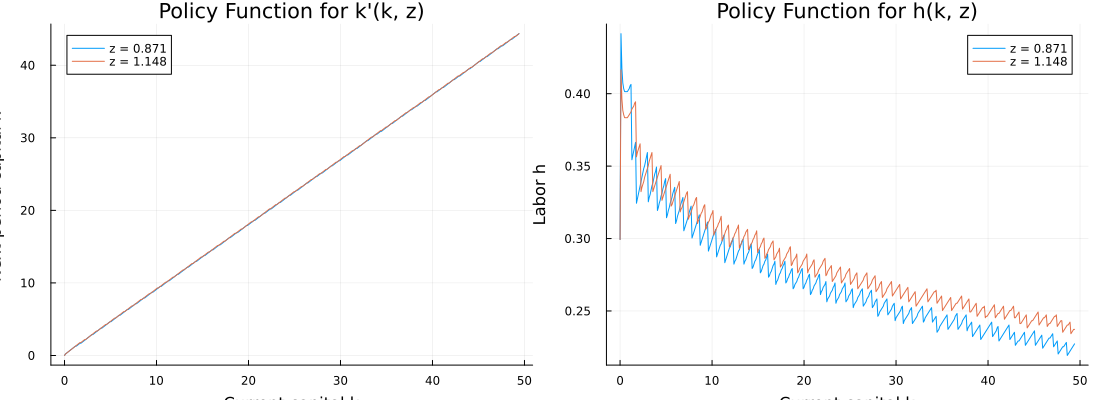

In [79]:
using Plots

# -------------------------------------------------------
# Plot policy functions
# Horizontal axis: current capital k
# Vertical axis: policy values
# Different productivity states z are shown as different lines
# -------------------------------------------------------

# Plot policy function for next-period capital k'(k, z)
p1 = plot(
    xlabel = "Current capital k",
    ylabel = "Next-period capital k'",
    title = "Policy Function for k'(k, z)",
    linewidth = 2
)

for iz in 1:length(z_grid)
    plot!(
        p1,
        k_grid,
        pol_kp_howard[:, iz],
        label = "z = $(round(z_grid[iz], digits=3))"
    )
end

# Plot policy function for labor h(k, z)
p2 = plot(
    xlabel = "Current capital k",
    ylabel = "Labor h",
    title = "Policy Function for h(k, z)",
    linewidth = 2
)

for iz in 1:length(z_grid)
    plot!(
        p2,
        k_grid,
        pol_h_howard[:, iz],
        label = "z = $(round(z_grid[iz], digits=3))"
    )
end

plot(p1, p2, layout = (1, 2), size = (1100, 400))